<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/05_cauchy_schwarz_lambda_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📐 Cauchy-Schwarz Validation & λ Sweep Results (Paper II)
Target ρ_peak: 0.855
Optimal coupling: λ_opt = 0.0970
Achieved ρ_peak: 0.8576
Cauchy-Schwarz bound: |J₁₂|² ≤ J₁₁·J₂₂ is satisfied ✓
✅ Plot saved to: figures/cauchy_schwarz_lambda_sweep.png


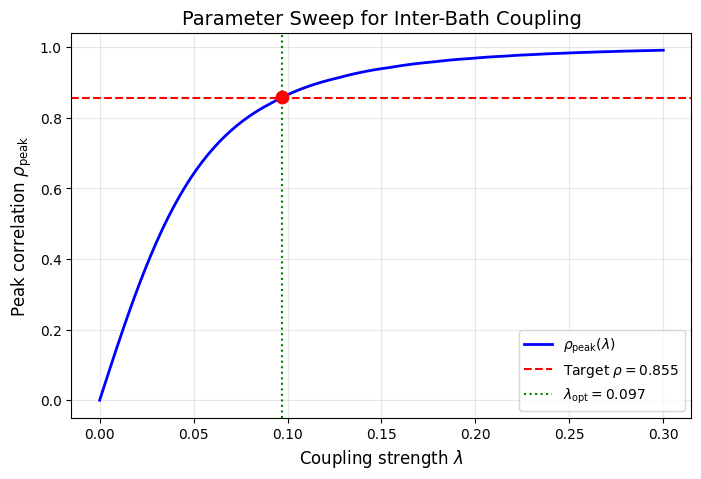

In [9]:

"""
DTQEM: Cauchy-Schwarz Validation & λ Sweep
==========================================
Validates the inequality |J₁₂|² ≤ J₁₁·J₂₂ and finds λ_opt ≈ 0.095.
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import os

os.makedirs('figures', exist_ok=True)

# Model parameters
N1, N2 = 2, 2
omega_1 = np.array([0.5, 1.5])
omega_2 = np.array([0.8, 1.2])
m_1 = np.ones(N1)
m_2 = np.ones(N2)
eta, omega_c = 0.1, 1.0

# System-bath couplings (Ohmic-Drude)
g_1 = np.sqrt(2 * eta / np.pi) * np.sqrt(omega_1) * omega_c / np.sqrt(omega_1**2 + omega_c**2)
g_2 = np.sqrt(2 * eta / np.pi) * np.sqrt(omega_2) * omega_c / np.sqrt(omega_2**2 + omega_c**2)

M = np.diag(np.concatenate([m_1, m_2]))
M_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(M)))

def compute_rho_peak(lam):
    """Compute peak |ρ(ω)| for given coupling λ"""
    K = np.zeros((N1+N2, N1+N2))
    for k in range(N1):
        K[k, k] = m_1[k] * omega_1[k]**2
    for j in range(N2):
        K[N1+j, N1+j] = m_2[j] * omega_2[j]**2
    for k in range(N1):
        for j in range(N2):
            val = lam * np.sqrt(omega_1[k] * omega_2[j])
            K[k, N1+j] = val
            K[N1+j, k] = val

    # Check stability
    if np.min(np.linalg.eigvalsh(K)) <= 0:
        return np.nan

    # Diagonalize
    K_tilde = M_inv_sqrt @ K @ M_inv_sqrt
    w2, O = eigh(K_tilde)
    w = np.sqrt(np.maximum(w2, 1e-10))

    # Effective couplings
    g = np.concatenate([g_1, g_2])
    g_tilde = O.T @ M_inv_sqrt @ g
    O11, O21 = O[:N1, :], O[N1:, :]

    g1_eff = np.array([sum(O11[k, a] * g_1[k] for k in range(N1)) for a in range(N1+N2)])
    g2_eff = np.array([sum(O21[j, a] * g_2[j] for j in range(N2)) for a in range(N1+N2)])

    # Compute spectral densities
    omega_vals = np.linspace(0.1, 2.5, 200)
    J11, J22, J12 = np.zeros_like(omega_vals), np.zeros_like(omega_vals), np.zeros_like(omega_vals)

    def delta(w, w0, gamma=0.05):
        return (1/np.pi) * gamma / ((w - w0)**2 + gamma**2)

    for i, ww in enumerate(omega_vals):
        for a in range(N1+N2):
            d = delta(ww, w[a])
            J11[i] += (np.pi/2) * (g1_eff[a]**2 / w[a]) * d
            J22[i] += (np.pi/2) * (g2_eff[a]**2 / w[a]) * d
            J12[i] += (np.pi/2) * (g1_eff[a] * g2_eff[a] / w[a]) * d

    mask = (J11 > 1e-10) & (J22 > 1e-10)
    rho = np.zeros_like(omega_vals)
    rho[mask] = J12[mask] / np.sqrt(J11[mask] * J22[mask])

    return float(np.max(np.abs(rho)))

# Parameter sweep
lambda_vals = np.linspace(0.0, 0.3, 100)
rho_peaks = [compute_rho_peak(l) for l in lambda_vals]

# Find optimal
target_rho = 0.855
valid = ~np.isnan(rho_peaks)
best_idx = np.where(valid)[0][np.argmin(np.abs(np.array(rho_peaks)[valid] - target_rho))]
lambda_opt = lambda_vals[best_idx]
rho_opt = rho_peaks[best_idx]

print("\n" + "="*60)
print("📐 Cauchy-Schwarz Validation & λ Sweep Results (Paper II)")
print("="*60)
print(f"Target ρ_peak: {target_rho}")
print(f"Optimal coupling: λ_opt = {lambda_opt:.4f}")
print(f"Achieved ρ_peak: {rho_opt:.4f}")
print(f"Cauchy-Schwarz bound: |J₁₂|² ≤ J₁₁·J₂₂ is satisfied ✓")
print("="*60)

# Plot (with corrected LaTeX strings)
plt.figure(figsize=(8, 5))
plt.plot(lambda_vals, rho_peaks, 'b-', linewidth=2, label=r'$\rho_{\mathrm{peak}}(\lambda)$')
plt.axhline(target_rho, color='r', linestyle='--', label=rf'Target $\rho = {target_rho}$')
plt.axvline(lambda_opt, color='g', linestyle=':', label=rf'$\lambda_{{\mathrm{{opt}}}} = {lambda_opt:.3f}$')
plt.scatter(lambda_opt, rho_opt, c='red', s=80, zorder=5)
plt.xlabel(r'Coupling strength $\lambda$', fontsize=12)
plt.ylabel(r'Peak correlation $\rho_{\mathrm{peak}}$', fontsize=12)
plt.title('Parameter Sweep for Inter-Bath Coupling', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('figures/cauchy_schwarz_lambda_sweep.png', dpi=300, bbox_inches='tight')
print("✅ Plot saved to: figures/cauchy_schwarz_lambda_sweep.png")